# 06 - Trade-off de Custo (FP vs FN) no Churn

## Objetivo deste notebook
Executar a **Tarefa 4 do TODO** com abordagem simples e didática: analisar o trade-off entre **falsos positivos (FP)** e **falsos negativos (FN)** no problema de churn.

Este notebook usa o dataset tratado (`Telco_customer_churn_ready.csv`) e um modelo baseline probabilístico para:
- gerar matriz de confusão em diferentes limiares;
- comparar métricas (precision, recall, F1, ROC-AUC, PR-AUC);
- simular impacto financeiro com base em CLTV e custo de campanha;
- recomendar um limiar orientado a negócio.

## Como estudar este notebook (passo a passo)
1. Entender os dados e a variável-alvo.
2. Treinar um modelo simples para obter probabilidades de churn.
3. Variar o limiar de decisão (`threshold`) para observar como FP e FN mudam.
4. Comparar duas visões de escolha de limiar: técnica (F1) e negócio (valor financeiro).

Ao final, você não vai ficar só com "qual métrica ficou maior", mas com **qual decisão gera mais valor** para a empresa.

## Premissas e observações
- Dataset: `data/Telco_customer_churn_ready.csv` (saída do notebook de EDA).
- Target: `Churn Value` (0 = não churn, 1 = churn).
- Variável de negócio: `CLTV` (valor do cliente).
- Modelo usado nesta análise: **Regressão Logística** (baseline robusto para dados tabulares).

### Premissas de custo (hipóteses)
As premissas abaixo podem ser ajustadas conforme decisão de negócio:
- `CUSTO_ACAO_RETENCAO`: custo de ativar campanha para um cliente sinalizado como churn.
- `TAXA_SUCESSO_RETENCAO`: percentual esperado de sucesso da ação em clientes realmente churn.

Com isso, o valor esperado por tipo de decisão é:
- **TP**: `TAXA_SUCESSO_RETENCAO * CLTV - CUSTO_ACAO_RETENCAO`
- **FP**: `-CUSTO_ACAO_RETENCAO`
- **FN**: `-CLTV`
- **TN**: `0`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.model_selection import train_test_split

# Reprodutibilidade: mantém o mesmo resultado em diferentes execuções.
SEED = 42
np.random.seed(SEED)

# Tenta localizar o dataset tratado em caminhos comuns (notebook aberto em pastas diferentes).
READY_PATH_CANDIDATES = [
    Path('../data/Telco_customer_churn_ready.csv'),
    Path('data/Telco_customer_churn_ready.csv'),
]

DATA_PATH = next((p for p in READY_PATH_CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, (
    'Arquivo tratado não encontrado. Execute o notebook 01_eda.ipynb para gerar Telco_customer_churn_ready.csv.'
)

print(f'Dataset encontrado em: {DATA_PATH.resolve()}')

Dataset encontrado em: C:\Users\azvef\Projeto FIAP 1\9mlet-tech-challenge-1-churn-prevision\data\Telco_customer_churn_ready.csv


In [2]:
# Lê o dataset já tratado no EDA (pronto para modelagem).
df = pd.read_csv(DATA_PATH)

TARGET = 'Churn Value'
assert TARGET in df.columns, 'Coluna alvo não encontrada.'
assert 'CLTV' in df.columns, 'Coluna CLTV não encontrada no dataset pronto.'

# X = variáveis explicativas; y = variável-alvo (0/1).
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Divide em treino e teste para avaliar generalização.
# test_size=0.2 -> 20% dos dados ficam "guardados" para avaliação final.
# stratify=y -> mantém a proporção de churn semelhante em treino e teste.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print('Shape geral:', df.shape)
print('Shape treino:', X_train.shape)
print('Shape teste :', X_test.shape)
print('Proporção churn (treino):', round(y_train.mean(), 4))
print('Proporção churn (teste) :', round(y_test.mean(), 4))

Shape geral: (7043, 1163)
Shape treino: (5634, 1162)
Shape teste : (1409, 1162)
Proporção churn (treino): 0.2654
Proporção churn (teste) : 0.2654


In [3]:
# Treinamos um baseline simples (Regressão Logística).
# Objetivo: gerar probabilidades de churn para cada cliente no teste.
model = LogisticRegression(max_iter=5000, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

# Probabilidade prevista para classe positiva (churn=1).
# Exemplo: y_proba = 0.72 significa 72% de chance de churn segundo o modelo.
y_proba = model.predict_proba(X_test)[:, 1]

# Métricas "sem threshold fixo":
# ROC-AUC mede capacidade geral de ordenar churn acima de não churn.
# PR-AUC é útil em classe desbalanceada, focando na classe positiva.
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC : {pr_auc:.4f}')

ROC-AUC: 0.8481
PR-AUC : 0.6462


## Simulação de custo por limiar
Nesta etapa fazemos uma varredura de limiar (threshold) e medimos:
- métricas de classificação;
- valor financeiro estimado com base em FP/FN/TP/TN.

In [4]:
# Premissas de negócio (ajustáveis).
CUSTO_ACAO_RETENCAO = 80.0
TAXA_SUCESSO_RETENCAO = 0.35

# Vamos testar vários limiares entre 0.05 e 0.95.
# Limiar baixo -> modelo classifica mais clientes como churn.
# Limiar alto -> modelo fica mais "conservador" e sinaliza menos clientes.
thresholds = np.linspace(0.05, 0.95, 19)
records = []

# CLTV será usado para traduzir erros/acertos em impacto financeiro.
cltv_test = X_test['CLTV'].values
y_true = y_test.values

for thr in thresholds:
    # Regra de decisão: se probabilidade >= limiar, marca como churn (1).
    y_pred = (y_proba >= thr).astype(int)

    # Matriz de confusão: TN, FP, FN, TP.
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Métricas clássicas dependentes do limiar atual.
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Máscaras para separar cada tipo de resultado.
    is_tp = (y_true == 1) & (y_pred == 1)
    is_fp = (y_true == 0) & (y_pred == 1)
    is_fn = (y_true == 1) & (y_pred == 0)

    # Regras de valor:
    # TP: recupera parte do CLTV, mas paga custo da ação.
    # FP: paga custo sem necessidade (cliente não sairia).
    # FN: perde o cliente (custo de oportunidade aproximado pelo CLTV).
    ganho_tp = (TAXA_SUCESSO_RETENCAO * cltv_test[is_tp] - CUSTO_ACAO_RETENCAO).sum()
    custo_fp = (-CUSTO_ACAO_RETENCAO * is_fp.sum())
    custo_fn = (-cltv_test[is_fn].sum())

    valor_total = ganho_tp + custo_fp + custo_fn

    records.append({
        'threshold': thr,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'valor_total': valor_total,
    })

tradeoff_df = pd.DataFrame(records)

# Melhor limiar técnico: maximiza F1.
best_f1_row = tradeoff_df.loc[tradeoff_df['f1'].idxmax()]

# Melhor limiar de negócio: maximiza valor financeiro.
best_value_row = tradeoff_df.loc[tradeoff_df['valor_total'].idxmax()]

# Exibe top 5 limiares por valor para facilitar interpretação.
display(tradeoff_df.sort_values('valor_total', ascending=False).head())

print('Melhor limiar por F1      :', round(float(best_f1_row['threshold']), 2))
print('Melhor limiar por valor   :', round(float(best_value_row['threshold']), 2))
print('Valor total máximo (R$)   :', round(float(best_value_row['valor_total']), 2))

,threshold,tn,fp,fn,tp,precision,recall,f1,valor_total
0,0.05,425,610,7,367,0.375640,0.981283,0.543301,411272.25
1,0.10,544,491,23,351,0.416865,0.938503,0.577303,332632.05
2,0.15,627,408,39,335,0.450875,0.895722,0.599821,255543.90
3,0.20,707,328,62,312,0.487500,0.834225,0.615385,131834.90
4,0.25,753,282,77,297,0.512953,0.794118,0.623295,43298.95


Melhor limiar por F1      : 0.35
Melhor limiar por valor   : 0.05
Valor total máximo (R$)   : 411272.25


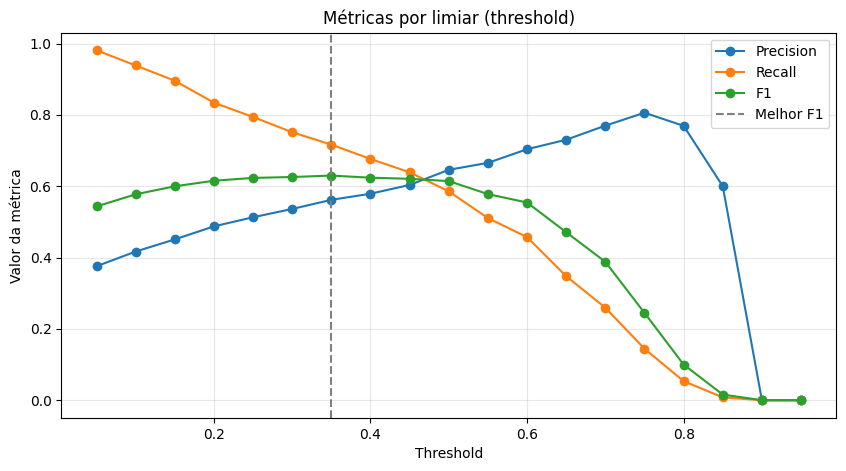

In [5]:
# Visual 1: Curvas de métricas por limiar.
plt.figure(figsize=(10, 5))
plt.plot(tradeoff_df['threshold'], tradeoff_df['precision'], marker='o', label='Precision')
plt.plot(tradeoff_df['threshold'], tradeoff_df['recall'], marker='o', label='Recall')
plt.plot(tradeoff_df['threshold'], tradeoff_df['f1'], marker='o', label='F1')
plt.axvline(best_f1_row['threshold'], linestyle='--', color='gray', label='Melhor F1')
plt.title('Métricas por limiar (threshold)')
plt.xlabel('Threshold')
plt.ylabel('Valor da métrica')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Como ler o gráfico de métricas por limiar
- Eixo X: limiar (`threshold`) usado para transformar probabilidade em classe 0/1.
- Eixo Y: valor da métrica (de 0 a 1).
- Curva **Precision**: entre os clientes previstos como churn, quantos realmente são churn.
- Curva **Recall**: entre os churns reais, quantos o modelo conseguiu capturar.
- Curva **F1**: equilíbrio entre precision e recall.

**Interpretação prática**:
- Se o limiar cai, geralmente recall sobe (captura mais churn), mas precision tende a cair (mais alarmes falsos).
- Se o limiar sobe, geralmente precision sobe, mas recall tende a cair (perde churn real).
- A linha vertical marca o melhor limiar por F1 (visão técnica).

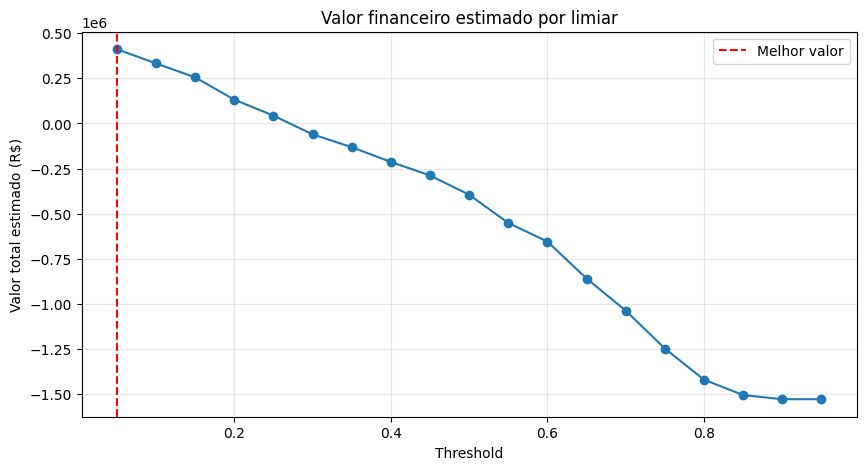

In [6]:
# Visual 2: Valor financeiro por limiar.
plt.figure(figsize=(10, 5))
plt.plot(tradeoff_df['threshold'], tradeoff_df['valor_total'], marker='o')
plt.axvline(best_value_row['threshold'], linestyle='--', color='red', label='Melhor valor')
plt.title('Valor financeiro estimado por limiar')
plt.xlabel('Threshold')
plt.ylabel('Valor total estimado (R$)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Como ler o gráfico de valor financeiro
- Eixo X: limiar testado.
- Eixo Y: valor total estimado com suas premissas de custo.
- Linha vertical vermelha: limiar que maximiza o valor total.

**Interpretação prática**:
- O melhor limiar financeiro pode ser diferente do melhor F1.
- Isso acontece porque o negócio "pesa" erros de forma desigual (FN pode custar muito mais que FP, por exemplo).
- O ponto mais alto da curva é o melhor ponto para decisão operacional, dado o cenário atual de custos.

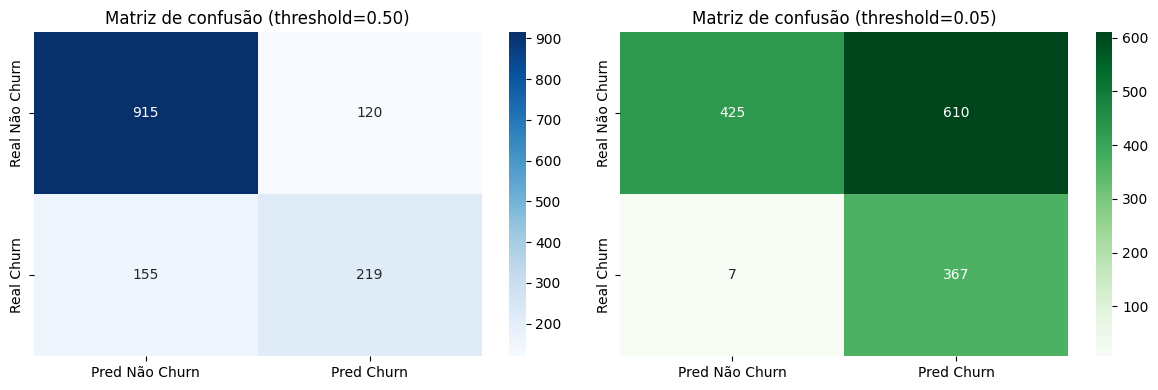

Leitura da matriz de confusão:
- Canto superior esquerdo (TN): cliente não churn corretamente classificado.
- Canto superior direito (FP): falso alarme; acionamos retenção sem necessidade.
- Canto inferior esquerdo (FN): churn perdido; cliente saiu sem ação.
- Canto inferior direito (TP): churn detectado corretamente para ação de retenção.


In [7]:
def confusion_df(y_true_arr, y_proba_arr, thr):
    # Converte probabilidade em classe binária com o limiar escolhido.
    y_pred_arr = (y_proba_arr >= thr).astype(int)
    cm = confusion_matrix(y_true_arr, y_pred_arr, labels=[0, 1])
    return pd.DataFrame(
        cm,
        index=['Real Não Churn', 'Real Churn'],
        columns=['Pred Não Churn', 'Pred Churn'],
    )

cm_050 = confusion_df(y_true, y_proba, 0.50)
cm_best = confusion_df(y_true, y_proba, float(best_value_row['threshold']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_050, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de confusão (threshold=0.50)')

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f"Matriz de confusão (threshold={float(best_value_row['threshold']):.2f})")

plt.tight_layout()
plt.show()

print('Leitura da matriz de confusão:')
print('- Canto superior esquerdo (TN): cliente não churn corretamente classificado.')
print('- Canto superior direito (FP): falso alarme; acionamos retenção sem necessidade.')
print('- Canto inferior esquerdo (FN): churn perdido; cliente saiu sem ação.')
print('- Canto inferior direito (TP): churn detectado corretamente para ação de retenção.')

## Conclusão da análise

### Leitura técnica
- ROC-AUC e PR-AUC indicam a capacidade de separação do modelo em cenário desbalanceado.
- F1 ajuda a equilibrar precision e recall quando o objetivo é não exagerar nem perder churns importantes.


### Leitura de negócio
- O limiar padrão (`0.50`) nem sempre maximiza retorno financeiro.
- O limiar ótimo por **valor total** tende a refletir melhor o custo real de FP e FN.


### Como traduzir para decisão real
1. Defina (com a área de negócio) quanto custa errar FP e FN.
2. Recalcule a curva de valor com essas premissas.
3. Escolha o limiar no pico da curva de valor.
4. Monitore mensalmente: se comportamento de clientes mudar, o limiar ótimo pode mudar também.


### Recomendação
Usar o limiar orientado por valor de negócio (definido no `best_value_row`) e revisá-lo conforme novas premissas de custo e taxa de sucesso de retenção.